Install Required Libraries

In [1]:


!pip -q install insightface
!pip -q install onnxruntime
!pip -q install opencv-python
!pip -q install scikit-learn
!pip -q install pandas
!pip -q install matplotlib
!pip -q install tqdm

print(" All required libraries installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 762.2/762.2 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 49.5 MB/s eta 0:00:00
 All required libraries installed successfully!


 Step 2: Import Required Libraries

In [2]:


# Standard Libraries
import os
import shutil
import zipfile
from pathlib import Path

# Computer Vision
import cv2

# Numerical Computing
import numpy as np

# Data Handling
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Progress Bar
from tqdm import tqdm

# Machine Learning
from sklearn.cluster import DBSCAN
from sklearn.metrics.pairwise import cosine_similarity

# InsightFace
from insightface.app import FaceAnalysis

print(" All libraries imported successfully!")

 All libraries imported successfully!


# Step 3: Upload Dataset

In [3]:


from google.colab import files
import os

print(" Please upload the dataset ZIP file...")
uploaded = files.upload()

# Get the uploaded ZIP filename automatically
zip_file = list(uploaded.keys())[0]

print(f"\n Uploaded File: {zip_file}")

 Please upload the dataset ZIP file...


Saving person_identification.zip to person_identification.zip

 Uploaded File: person_identification.zip


Step 4: Extract Dataset

In [5]:

import os
import shutil
import zipfile

# Folder where dataset will be extracted
extract_path = "/content/person_identification"

# Remove old extracted folder if it exists
if os.path.exists(extract_path):
    shutil.rmtree(extract_path)

# Create fresh folder
os.makedirs(extract_path, exist_ok=True)

# Extract ZIP
with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print(" Dataset extracted successfully!")
print(f" Dataset Location: {extract_path}")

 Dataset extracted successfully!
 Dataset Location: /content/person_identification


# Step 5: Inspect Extracted Dataset Structure

In [6]:


import os

print(" Extracted Dataset Structure:\n")

for root, dirs, files in os.walk(extract_path):
    print(f"Folder: {root}")
    print(f"Subfolders: {dirs}")
    print(f"Files: {len(files)}")

    if len(files) > 0:
        print("Sample Files:", files[:5])

    print("-" * 60)

 Extracted Dataset Structure:

Folder: /content/person_identification
Subfolders: []
Files: 6
Sample Files: ['person_03_1.jpg', 'person_03_0.jpg', 'person_01_0.jpg', 'person_02_0.jpg', 'person_02_1.jpg']
------------------------------------------------------------


 Step 6: Load All Image Paths

In [7]:

from pathlib import Path

# Supported image formats
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}

# Dataset folder
image_folder = Path(extract_path)

# Collect all image paths
image_paths = sorted([
    img for img in image_folder.iterdir()
    if img.suffix.lower() in IMAGE_EXTENSIONS
])

print("=" * 60)
print("Dataset Loaded Successfully")
print("=" * 60)

print(f"Image Folder : {image_folder}")
print(f"Total Images : {len(image_paths)}")

print("\nImage List:")

for img in image_paths:
    print(img.name)

Dataset Loaded Successfully
Image Folder : /content/person_identification
Total Images : 6

Image List:
person_01_0.jpg
person_01_1.jpg
person_02_0.jpg
person_02_1.jpg
person_03_0.jpg
person_03_1.jpg


Step 7: Display Dataset Images

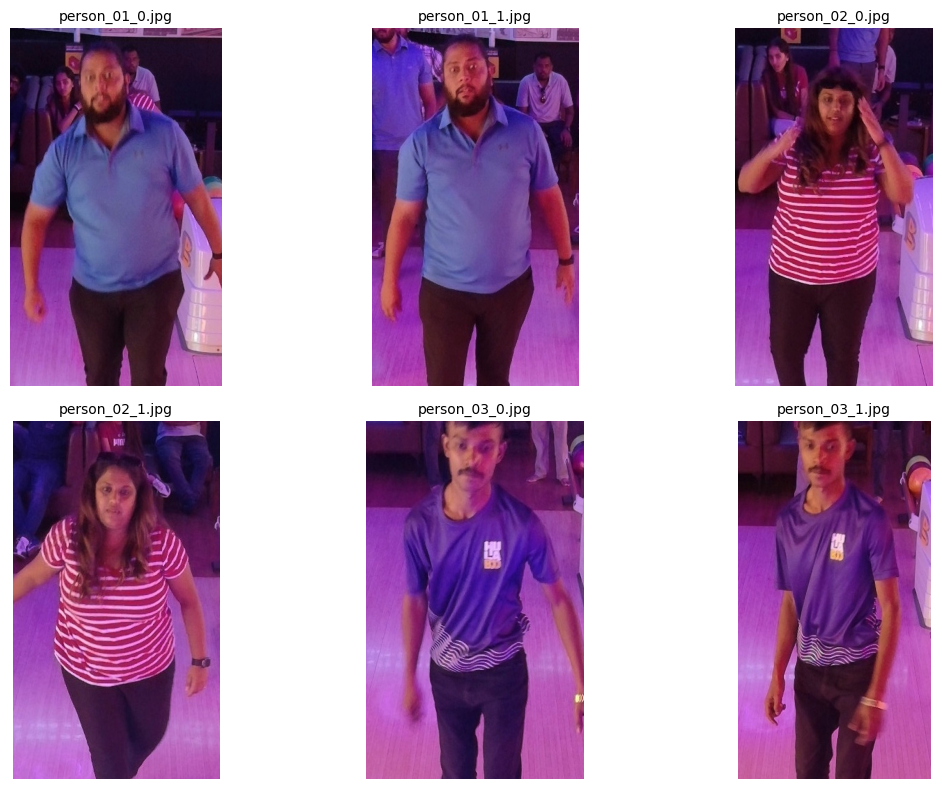

In [8]:

import cv2
import matplotlib.pyplot as plt
import math

num_images = len(image_paths)
cols = 3
rows = math.ceil(num_images / cols)

plt.figure(figsize=(12, 4 * rows))

for i, img_path in enumerate(image_paths):

    # Read image using OpenCV
    image = cv2.imread(str(img_path))

    # Check if image loaded successfully
    if image is None:
        print(f" Could not read: {img_path.name}")
        continue

    # Convert BGR to RGB for display
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(rows, cols, i + 1)
    plt.imshow(image)
    plt.title(img_path.name, fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()

Step 8: Initialize InsightFace

In [9]:


from insightface.app import FaceAnalysis

print("Loading InsightFace model... (first run may take 1-2 minutes)")

# Initialize the model
app = FaceAnalysis(
    name="buffalo_l",
    providers=["CPUExecutionProvider"]   # Use CPU (works on every Colab runtime)
)

# Load detection and recognition models
app.prepare(
    ctx_id=0,
    det_size=(640, 640)
)

print("\n InsightFace initialized successfully!")

Loading InsightFace model... (first run may take 1-2 minutes)
download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:03<00:00, 84840.07KB/s] 


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)

 InsightFac

Step 9: Extract Face Embeddings

In [10]:

embeddings = []
image_names = []
failed_images = []

print("Extracting face embeddings...\n")

for img_path in tqdm(image_paths):

    # Read image
    image = cv2.imread(str(img_path))

    # Check if image was loaded successfully
    if image is None:
        print(f" Could not read image: {img_path.name}")
        failed_images.append(img_path.name)
        continue

    try:
        # Detect faces
        faces = app.get(image)

        # No face detected
        if len(faces) == 0:
            print(f" No face detected: {img_path.name}")
            failed_images.append(img_path.name)
            continue

        # Multiple faces detected
        elif len(faces) > 1:

            print(f" Multiple faces detected: {img_path.name}")

            # Select the largest face
            face = max(
                faces,
                key=lambda f: (f.bbox[2] - f.bbox[0]) * (f.bbox[3] - f.bbox[1])
            )

        else:
            face = faces[0]

        # ArcFace normalized embedding (512 dimensions)
        embedding = face.normed_embedding

        embeddings.append(embedding)
        image_names.append(img_path.name)

    except Exception as e:
        print(f" Error processing {img_path.name}: {e}")
        failed_images.append(img_path.name)

# Convert embeddings into NumPy array
embeddings = np.array(embeddings)

print("\n" + "=" * 60)
print("Embedding Extraction Summary")
print("=" * 60)

print(f" Successfully Processed : {len(image_names)}")
print(f" Failed Images          : {len(failed_images)}")
print(f" Embedding Shape        : {embeddings.shape}")

if failed_images:
    print("\nFailed Images:")
    for img in failed_images:
        print("-", img)

Extracting face embeddings...



 17%|█▋        | 1/6 [00:02<00:11,  2.28s/it]

 Multiple faces detected: person_01_0.jpg


 33%|███▎      | 2/6 [00:03<00:06,  1.68s/it]

 Multiple faces detected: person_01_1.jpg


 50%|█████     | 3/6 [00:04<00:04,  1.49s/it]

 Multiple faces detected: person_02_0.jpg


100%|██████████| 6/6 [00:09<00:00,  1.64s/it]


Embedding Extraction Summary
 Successfully Processed : 6
 Failed Images          : 0
 Embedding Shape        : (6, 512)


Step 10: Cluster Face Embeddings using DBSCAN

In [11]:

# DBSCAN parameters
EPS = 0.45          # Cosine distance threshold
MIN_SAMPLES = 2     # Minimum images to form a cluster

dbscan = DBSCAN(
    eps=EPS,
    min_samples=MIN_SAMPLES,
    metric="cosine"
)

# Predict cluster labels
cluster_labels = dbscan.fit_predict(embeddings)

# Store results
results = pd.DataFrame({
    "Image": image_names,
    "Cluster_ID": cluster_labels
})

print("=" * 60)
print("Clustering Completed")
print("=" * 60)

print(results)

print("\nCluster Summary:")

unique_clusters = sorted(set(cluster_labels))

for cluster in unique_clusters:

    if cluster == -1:
        print(f"Noise Images (-1): {(cluster_labels == cluster).sum()}")

    else:
        print(f"Cluster {cluster}: {(cluster_labels == cluster).sum()} images")

Clustering Completed
             Image  Cluster_ID
0  person_01_0.jpg           0
1  person_01_1.jpg           0
2  person_02_0.jpg           1
3  person_02_1.jpg           1
4  person_03_0.jpg           2
5  person_03_1.jpg           2

Cluster Summary:
Cluster 0: 2 images
Cluster 1: 2 images
Cluster 2: 2 images


 Step 11: Compute Confidence Scores

In [12]:


confidence_scores = []

# Process each cluster separately
for cluster_id in cluster_labels:

    # Noise points
    if cluster_id == -1:
        confidence_scores.append(0.0)
        continue

    # Get indices belonging to this cluster
    cluster_indices = np.where(cluster_labels == cluster_id)[0]

    # Get embeddings of this cluster
    cluster_embeddings = embeddings[cluster_indices]

    # Compute cluster centroid
    centroid = np.mean(cluster_embeddings, axis=0)

    # Normalize centroid
    centroid = centroid / np.linalg.norm(centroid)

    # Current image embedding
    current_embedding = embeddings[len(confidence_scores)]

    # Cosine similarity with centroid
    similarity = np.dot(current_embedding, centroid)

    # Convert similarity to percentage
    confidence = max(0, similarity) * 100

    confidence_scores.append(round(confidence, 2))

# Add confidence scores to results
results["Confidence (%)"] = confidence_scores

print("=" * 70)
print("Final Results")
print("=" * 70)

display(results)

Final Results


,Image,Cluster_ID,Confidence (%)
0,person_01_0.jpg,0,91.800003
1,person_01_1.jpg,0,91.800003
2,person_02_0.jpg,1,88.290001
3,person_02_1.jpg,1,88.290001
4,person_03_0.jpg,2,92.820000
5,person_03_1.jpg,2,92.820000


 Step 12: Generate Output Folders and CSV Report

In [13]:

import shutil
from pathlib import Path

# Output directory
output_dir = Path("/content/output_clusters")

# Remove previous output if it exists
if output_dir.exists():
    shutil.rmtree(output_dir)

output_dir.mkdir(parents=True, exist_ok=True)

# Create folders and copy images
for _, row in results.iterrows():

    image_name = row["Image"]
    cluster_id = row["Cluster_ID"]

    # Noise images
    if cluster_id == -1:
        cluster_folder = output_dir / "unclustered"
    else:
        cluster_folder = output_dir / f"cluster_{cluster_id}"

    cluster_folder.mkdir(exist_ok=True)

    src = image_folder / image_name
    dst = cluster_folder / image_name

    shutil.copy(src, dst)

# Save CSV report
report_path = output_dir / "report.csv"
results.to_csv(report_path, index=False)

print("=" * 70)
print(" Output Generated Successfully")
print("=" * 70)
print(f" Output Folder : {output_dir}")
print(f" Report        : {report_path}")

 Output Generated Successfully
 Output Folder : /content/output_clusters
 Report        : /content/output_clusters/report.csv


Step 13: Display Final Results

In [14]:

print("=" * 80)
print("FINAL CLUSTERING RESULTS")
print("=" * 80)

display(results)

print("\nCluster Summary")

for cluster in sorted(results["Cluster_ID"].unique()):

    if cluster == -1:
        count = (results["Cluster_ID"] == -1).sum()
        print(f"Unclustered Images : {count}")

    else:
        count = (results["Cluster_ID"] == cluster).sum()
        print(f"Cluster {cluster} : {count} images")

FINAL CLUSTERING RESULTS


,Image,Cluster_ID,Confidence (%)
0,person_01_0.jpg,0,91.800003
1,person_01_1.jpg,0,91.800003
2,person_02_0.jpg,1,88.290001
3,person_02_1.jpg,1,88.290001
4,person_03_0.jpg,2,92.820000
5,person_03_1.jpg,2,92.820000



Cluster Summary
Cluster 0 : 2 images
Cluster 1 : 2 images
Cluster 2 : 2 images


Step 14: Download Results

In [15]:

import shutil
from google.colab import files

zip_file = shutil.make_archive(
    "/content/output_clusters",
    "zip",
    "/content/output_clusters"
)

print(" Output ZIP Created")

files.download(zip_file)

 Output ZIP Created


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>